# PHÂN TÍCH CHẤT LƯỢNG CÂU HỎI CỦA CÁC ĐỀ THI CHUẨN HOÁ VÀ ĐÁNH GIÁ NĂNG LỰC THÍ SINH

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import irt
import ctt

In [96]:
df_dot1 = pd.read_csv("lan1.csv")
df_dot2 = pd.read_csv("lan2.csv")
da_1 = pd.read_csv("ans_1.csv", delimiter=";")
da_2 = pd.read_csv("ans_2.csv", delimiter=";")

df_dot1.drop_duplicates(subset=['Email'], keep='last', inplace=True)
df_dot2.drop_duplicates(subset=['Email'], keep='last', inplace=True)

In [97]:
df_dot1, df_dot2, da_1, da_2

(        SBD                     Timestamp  \
 0    110001   2025/10/19 4:46:46 PM GMT+7   
 1    110002   2025/10/18 1:05:06 PM GMT+7   
 2    110003  2025/10/19 12:42:42 PM GMT+7   
 3    110004   2025/10/19 5:48:44 PM GMT+7   
 4    110005   2025/10/18 1:25:28 PM GMT+7   
 ..      ...                           ...   
 471  110472   2025/10/11 3:07:53 PM GMT+7   
 472  110473  2025/10/19 12:00:37 AM GMT+7   
 473  110474   2025/10/03 9:24:46 PM GMT+7   
 474  110475  2025/10/18 10:14:54 PM GMT+7   
 475  110476                           NaN   
 
                                    Email                   Name Gioi  MaDe  \
 0             07vudinhchien8a2@gmail.com          Vũ Đình Chiến  Nam   107   
 1                    09022008a@gmail.com                 beaver   Nữ   107   
 2    19.nguyenminhtuankiet.9.1@gmail.com  Nguyễn Minh Tuấn Kiệt  Nam   107   
 3      2008.lvklinh.nguyenhien@gmail.com              kling_296   Nữ   107   
 4                2008trankhanh@gmail.com        Tr

In [98]:
# Tổng số thí sinh thi mỗi đề
print(f'Tổng số thí sinh thi đề 1: {df_dot1.shape[0]}')
print(f'Tổng số thí sinh thi đề 2: {df_dot2.shape[0]}')

Tổng số thí sinh thi đề 1: 469
Tổng số thí sinh thi đề 2: 752


In [99]:
thisinh_1 = pd.Series(df_dot1['Email'])
thisinh_2 = pd.Series(df_dot2['Email'])

# cho biết có bao nhiêu thí sinh nào thi cả 2 đề hay chỉ thi 1 trong 2 đề
thisinh_both = pd.Series(list(set(thisinh_1) & set(thisinh_2)))
thisinh_only1 = pd.Series(list(set(thisinh_1) - set(thisinh_2)))
thisinh_only2 = pd.Series(list(set(thisinh_2) - set(thisinh_1)))
print('--- Thống kê thí sinh có tham gia thi 2 đề ---')
print(f'Số thí sinh thi cả 2 đề: {thisinh_both.shape[0]}')
print(f'Số thí sinh chỉ thi đề 1: {thisinh_only1.shape[0]}')
print(f'Số thí sinh chỉ thi đề 2: {thisinh_only2.shape[0]}')

--- Thống kê thí sinh có tham gia thi 2 đề ---
Số thí sinh thi cả 2 đề: 241
Số thí sinh chỉ thi đề 1: 228
Số thí sinh chỉ thi đề 2: 511


In [100]:
gioi= pd.DataFrame(
    {'Đề 1': df_dot1['Gioi'],
    'Đề 2': df_dot2['Gioi']}
)

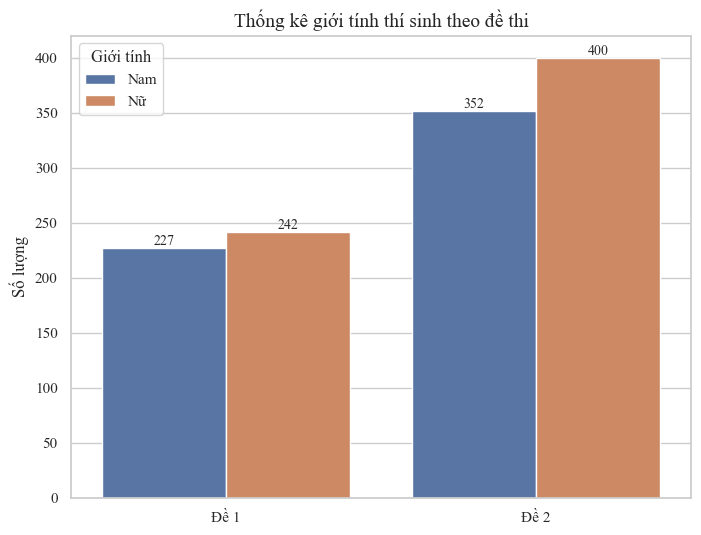

In [101]:
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] 
plt.figure(figsize=(8, 6))
sns.countplot(data=gioi.melt(var_name='Đề', value_name='Giới tính'), x='Đề', hue='Giới tính')
plt.title('Thống kê giới tính thí sinh theo đề thi', fontsize=14)
plt.xlabel(None)
plt.ylabel('Số lượng')
#thêm nhãn trên mỗi cột
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=10)


In [102]:
# lập thành bảng thống kê
gioi_counts = gioi.apply(pd.Series.value_counts).astype(int)
gioi_counts

,Đề 1,Đề 2
Nữ,242,400
Nam,227,352


In [103]:
# Hàm chuyển đổi đáp án thành giá trị (0 là sai hoặc không làm, 1 là đúng, -1 là trống)
def chamDiem(x, answer):
    ma_de = x['MaDe']
    row = answer.loc[answer['MaDe'] == ma_de]
    
    for i in range(1, 121):
        thi_sinh_dap_an = str(x.get(f'Cau{i}', '')).strip().upper()
        
        # Lấy đáp án đúng nếu tồn tại
        if not row.empty:
            dap_an_dung = str(row.iloc[0].get(f'Cau{i}', '')).strip().upper()
        else:
            dap_an_dung = ''

        # Xử lý các trường hợp đặc biệt
        if pd.isna(dap_an_dung):     # Xử lý chặn trên và sai đề
            x[f'Cau{i}'] = 1
        elif pd.isna(x[f'Cau{i}']): # xử lý bỏ trống câu hỏi
            x[f'Cau{i}'] = -1
        else:
            # Tách các đáp án đúng theo dấu /
            cac_dap_an = [da.strip() for da in dap_an_dung.split('/')]
            # Xử lý kết quả bài làm
            x[f'Cau{i}'] = 1 if thi_sinh_dap_an in cac_dap_an else 0

    return x

def ketQuaCham(df, answer):
    df_chamdiem = df.copy()
    df_chamdiem = df_chamdiem.apply(lambda x: chamDiem(x, answer), axis=1)
    return df_chamdiem

df_chamdiem_1 = ketQuaCham(df_dot1, da_1)
df_chamdiem_2 = ketQuaCham(df_dot2, da_2)

In [104]:
# tách thành 4 DataFrame tương ứng với 4 phần thì, mỗi phần 30 câu hỏi
def tach_phan(df_chamdiem):
    df_info = df_chamdiem[['SBD', 'MaDe', 'Gioi']]
    df_TV = pd.concat([df_info, df_chamdiem[[f'Cau{i}' for i in range(1, 31)]]], axis=1)
    df_TA = pd.concat([df_info, df_chamdiem[[f'Cau{i}' for i in range(31, 61)]]], axis=1)
    df_TO = pd.concat([df_info, df_chamdiem[[f'Cau{i}' for i in range(61, 91)]]], axis=1)
    df_KH = pd.concat([df_info, df_chamdiem[[f'Cau{i}' for i in range(91, 121)]]], axis=1)
    return df_TV, df_TA, df_TO, df_KH

# hàm tính điểm thô (số câu đúng) và đếm số câu thí sinh bỏ trống
def tinh_diem(df_chamdiem):
    df_chamdiem['Raw'] = df_chamdiem[[f'{i}' for i in df_chamdiem.columns if i.startswith('Cau')]].apply(lambda x: sum(x == 1), axis=1)
    df_chamdiem['Null'] = df_chamdiem[[f'{i}' for i in df_chamdiem.columns if i.startswith('Cau')]].apply(lambda x: sum(x == -1), axis=1)
    return df_chamdiem

df_TV1, df_TA1, df_TO1, df_KH1 = tach_phan(df_chamdiem_1)
df_TV2, df_TA2, df_TO2, df_KH2 = tach_phan(df_chamdiem_2)

for data in [df_TV1, df_TA1, df_TO1, df_KH1, df_TV2, df_TA2, df_TO2, df_KH2]:
    data = tinh_diem(data)


In [105]:
# Vẽ biểu đồ thành phần 
def draw_plot(df, col_name: str, title: str, range):
    sns.set_theme(style="whitegrid")
    plt.rcParams['font.family'] = 'serif'  # or 'sans-serif', 'monospace', 'cursive', 'fantasy'
    plt.rcParams['font.serif'] = ['Times New Roman'] 
    fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(16, 9))

    sns.histplot(df[f'{col_name}TV'], bins=30, binrange=range, ax=axes[0, 0], kde=False, color="b")
    axes[0, 0].set_xlabel('Tiếng Việt')
    axes[0, 0].set_ylabel('Số lượng')
    #thêm giá trị vào từng cột
    for p in axes[0, 0].patches:
        height = p.get_height()
        if height > 0:
            axes[0, 0].annotate(f'{int(height)}', 
                             (p.get_x() + p.get_width() / 2., height),
                             ha='center', va='bottom', fontsize=12)

    sns.histplot(df[f'{col_name}TA'], bins=30, binrange=range, ax=axes[0, 1], kde=False, color="r")
    axes[0, 1].set_xlabel('Tiếng Anh')
    axes[0, 1].set_ylabel('Số lượng')
    for p in axes[0, 1].patches:
        height = p.get_height()
        if height > 0:
            axes[0, 1].annotate(f'{int(height)}', 
                             (p.get_x() + p.get_width() / 2., height),
                             ha='center', va='bottom', fontsize=12)

    sns.histplot(df[f'{col_name}TO'], bins=30, binrange=range, ax=axes[1, 0], kde=False, color="orange")
    axes[1, 0].set_xlabel('Toán')
    axes[1, 0].set_ylabel('Số lượng')
    for p in axes[1, 0].patches:   
        height = p.get_height()
        if height > 0:
            axes[1, 0].annotate(f'{int(height)}', 
                             (p.get_x() + p.get_width() / 2., height),
                             ha='center', va='bottom', fontsize=12)

    sns.histplot(df[f'{col_name}KH'], bins=30, binrange=range, ax=axes[1, 1], kde=False, color="g")
    axes[1, 1].set_xlabel('Tư duy khoa học')
    axes[1, 1].set_ylabel('Số lượng')
    for p in axes[1, 1].patches:
        height = p.get_height()
        if height > 0:
            axes[1, 1].annotate(f'{int(height)}', 
                             (p.get_x() + p.get_width() / 2., height),
                             ha='center', va='bottom', fontsize=12)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.xlim(range[0], range[1])
    plt.show()

In [106]:
df_TV1

,SBD,MaDe,Gioi,Cau1,Cau2,Cau3,Cau4,Cau5,Cau6,Cau7,...,Cau23,Cau24,Cau25,Cau26,Cau27,Cau28,Cau29,Cau30,Raw,Null
0,110001,107,Nam,1,1,0,1,0,1,0,...,0,1,1,1,1,1,1,0,21,1
1,110002,107,Nữ,1,1,1,0,-1,-1,1,...,0,1,1,1,-1,1,1,0,16,4
2,110003,107,Nam,0,1,1,0,0,1,0,...,1,1,1,1,1,1,1,0,19,0
3,110004,107,Nữ,0,1,1,0,0,1,0,...,0,1,1,1,1,1,1,1,16,0
4,110005,107,Nam,1,1,1,0,1,1,0,...,1,0,1,0,1,1,1,1,20,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471,110472,107,Nữ,1,1,1,1,1,1,1,...,0,0,1,1,1,1,1,0,20,0
472,110473,107,Nữ,1,1,1,0,0,1,1,...,1,1,1,0,1,1,1,0,20,0
473,110474,107,Nữ,1,1,1,0,0,0,0,...,1,0,1,1,0,1,0,0,15,0
474,110475,107,Nữ,1,1,1,1,0,1,1,...,1,0,1,0,1,1,1,0,15,0


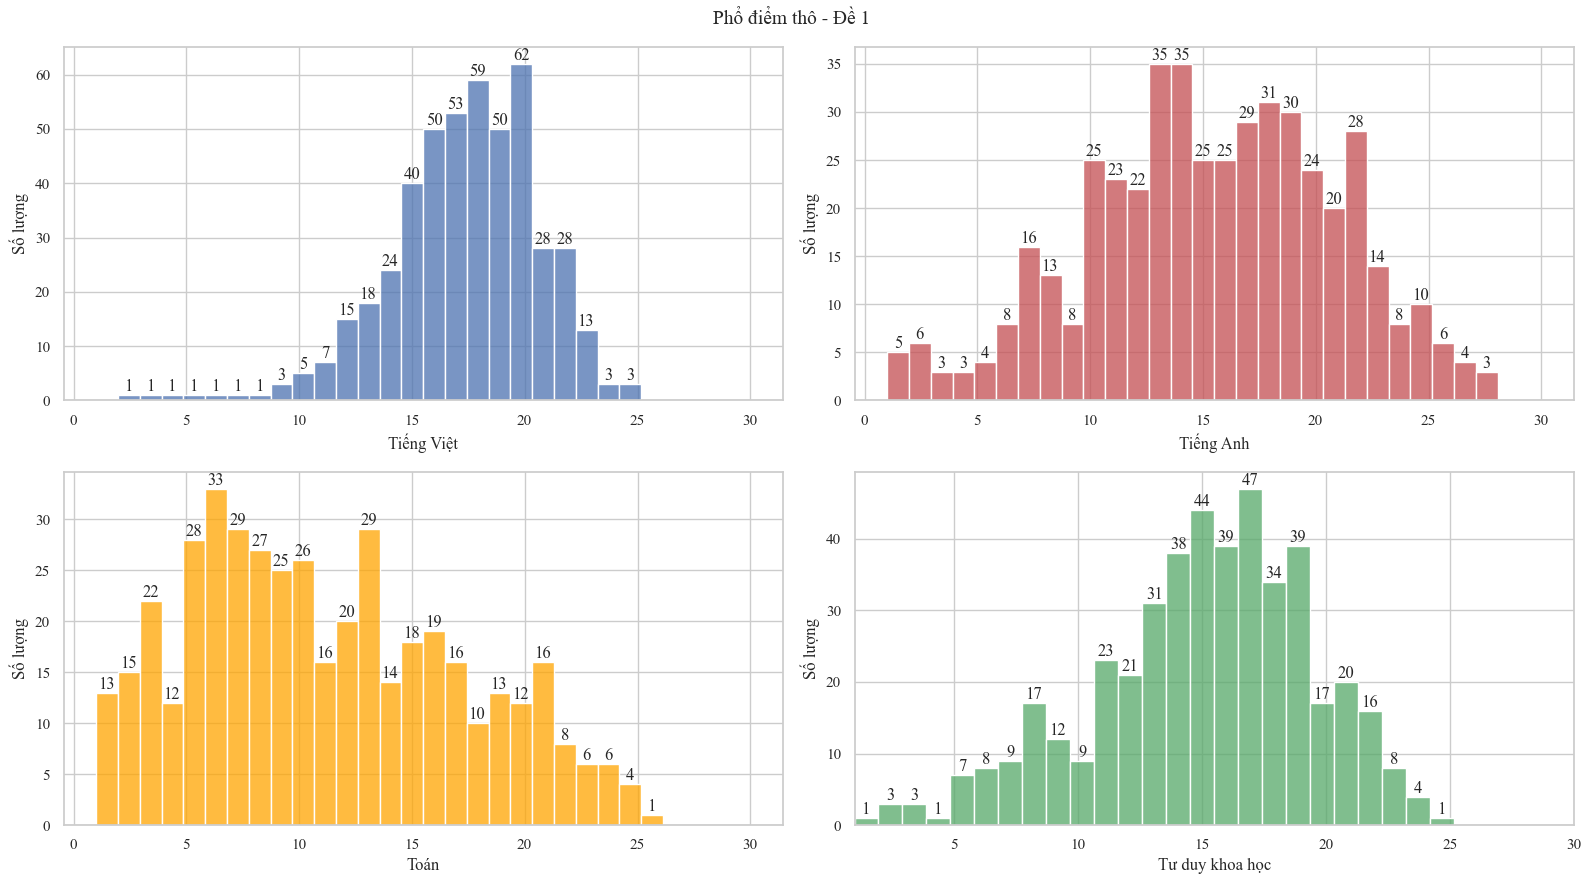

In [107]:
df_raw1 = df_TV1[['SBD', 'Raw']].copy().rename({'Raw': 'RawTV'}, axis=1)

df_raw1 = df_raw1.merge(df_TA1[['SBD', 'Raw']].rename({'Raw': 'RawTA'}, axis=1), on='SBD', how='outer')
df_raw1 = df_raw1.merge(df_TO1[['SBD', 'Raw']].rename({'Raw': 'RawTO'}, axis=1), on='SBD', how='outer')
df_raw1 = df_raw1.merge(df_KH1[['SBD', 'Raw']].rename({'Raw': 'RawKH'}, axis=1), on='SBD', how='outer')

draw_plot(df_raw1, col_name='Raw', title='Phổ điểm thô - Đề 1', range=(1,30))

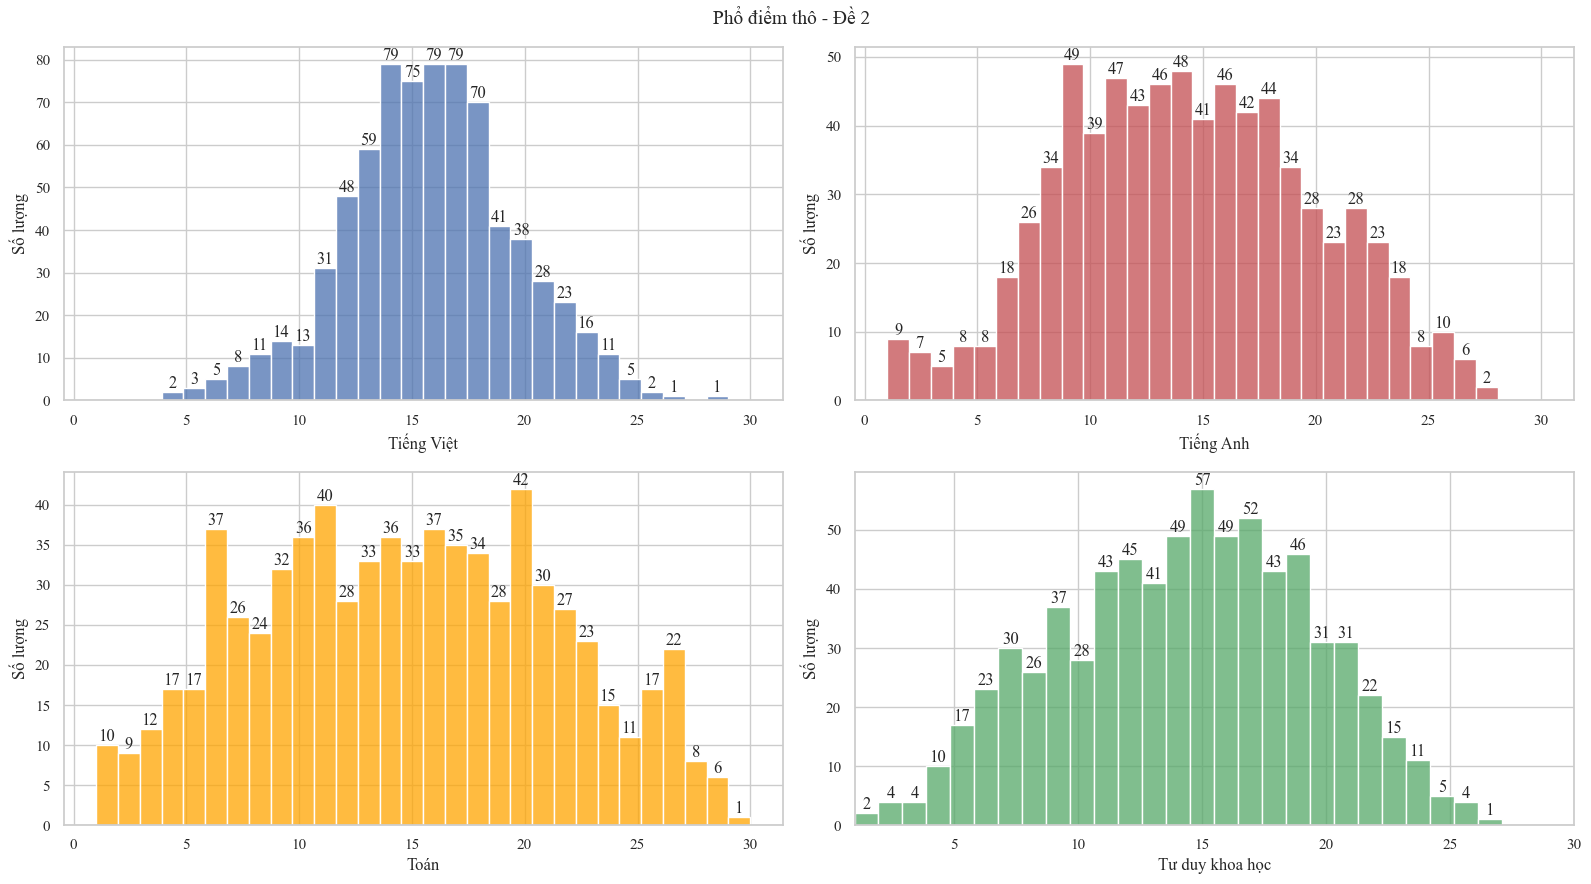

In [108]:
df_raw2 = df_TV2[['SBD', 'Raw']].copy().rename({'Raw': 'RawTV'}, axis=1)

df_raw2 = df_raw2.merge(df_TA2[['SBD', 'Raw']].rename({'Raw': 'RawTA'}, axis=1), on='SBD', how='outer')
df_raw2 = df_raw2.merge(df_TO2[['SBD', 'Raw']].rename({'Raw': 'RawTO'}, axis=1), on='SBD', how='outer')
df_raw2 = df_raw2.merge(df_KH2[['SBD', 'Raw']].rename({'Raw': 'RawKH'}, axis=1), on='SBD', how='outer')
draw_plot(df_raw2, col_name='Raw', title='Phổ điểm thô - Đề 2', range=(1,30))

In [109]:
rawtotal_1 = pd.Series(df_TV1['Raw'] + df_TA1['Raw'] + df_TO1['Raw'] + df_KH1['Raw'])
rawtotal_2 = pd.Series(df_TV2['Raw'] + df_TA2['Raw'] + df_TO2['Raw'] + df_KH2['Raw'])


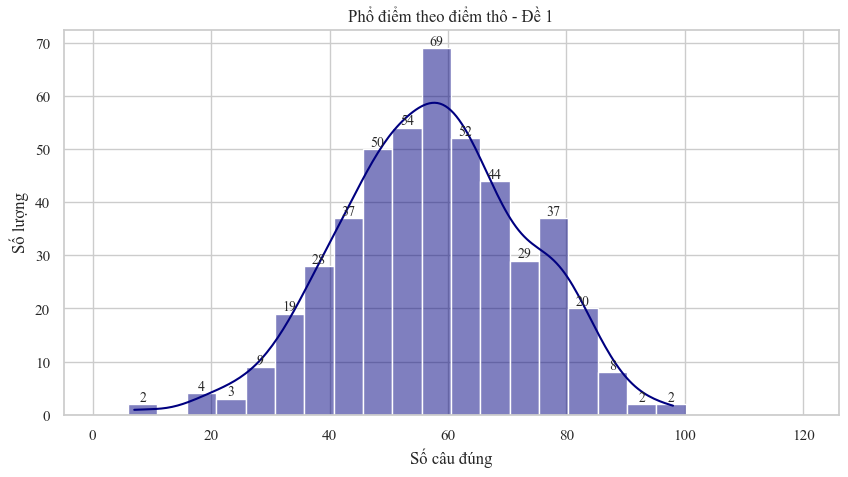

In [110]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,5))
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] 

sns.histplot(rawtotal_1, bins=24, binrange=(1, 120), kde=True, color='navy')
#thêm giá trị vào từng cột
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{int(height)}', 
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center',va='bottom', fontsize=10)

plt.title('Phổ điểm theo điểm thô - Đề 1')
plt.xlabel("Số câu đúng")
plt.ylabel("Số lượng")

plt.show()

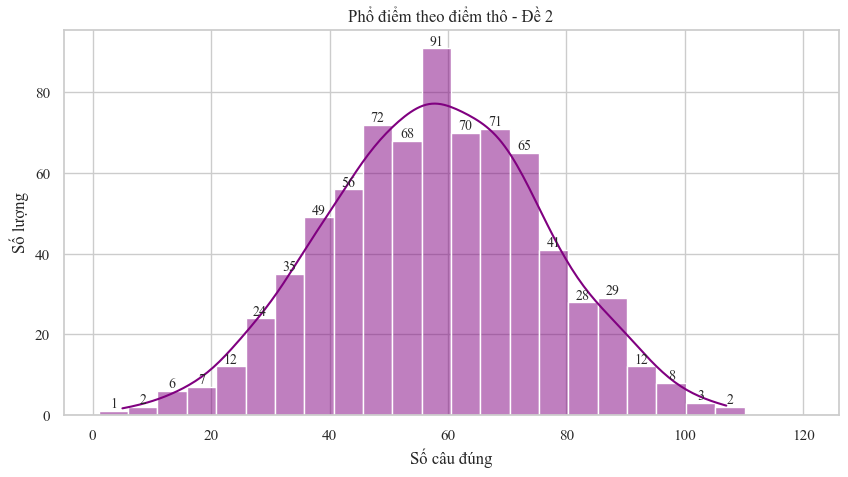

In [111]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,5))
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] 

sns.histplot(rawtotal_2, bins=24, binrange=(1, 120), kde=True, color='purple')
#thêm giá trị vào từng cột
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{int(height)}', 
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center',va='bottom', fontsize=10)

plt.title('Phổ điểm theo điểm thô - Đề 2')
plt.xlabel("Số câu đúng")
plt.ylabel("Số lượng")

plt.show()

In [112]:
b_1, b_2 =  pd.DataFrame(), pd.DataFrame()
for data in [df_TV1, df_TA1, df_TO1, df_KH1]:
    b = (ctt.cal_diff(data[data['Null'] < 30])) # loại những thí sinh không thi 1 phần (bỏ toàn bộ câu hỏi của phần thi đó)
    b_1 = pd.concat([b_1, b], axis=0)

for data in [df_TV2, df_TA2, df_TO2, df_KH2]:
    b = (ctt.cal_diff(data[data['Null'] < 30])) # loại những thí sinh không thi 1 phần (bỏ toàn bộ câu hỏi của phần thi đó)
    b_2 = pd.concat([b_2, b], axis=0)

b_1 = b_1.rename({0: 'CTT'}, axis=1)
b_2 = b_2.rename({0: 'CTT'}, axis=1)

In [113]:
b_1['CTT'].describe()

count    120.000000
mean       0.489165
std        0.216320
min        0.031674
25%        0.316082
50%        0.465665
75%        0.625000
max        0.929487
Name: CTT, dtype: float64

In [114]:
b_2.describe()

,CTT
count,120.000000
mean,0.492247
std,0.182863
min,0.084906
25%,0.374675
50%,0.461228
75%,0.613752
max,0.913747


In [115]:
def b_category(diff):
    if diff > 0.9:
        return 'Rất dễ'
    elif diff > 0.75:
        return 'Dễ'
    elif diff > 0.6:
        return 'Tương đối dễ'
    elif diff > 0.4:
        return 'Bình thường'
    elif diff > 0.25:
        return 'Tương đối khó'
    elif diff > 0.1:
        return 'Khó'
    else:
        return 'Rất khó'
    
b_1['Phân loại'] = b_1['CTT'].apply(b_category)
b_2['Phân loại'] = b_2['CTT'].apply(b_category)

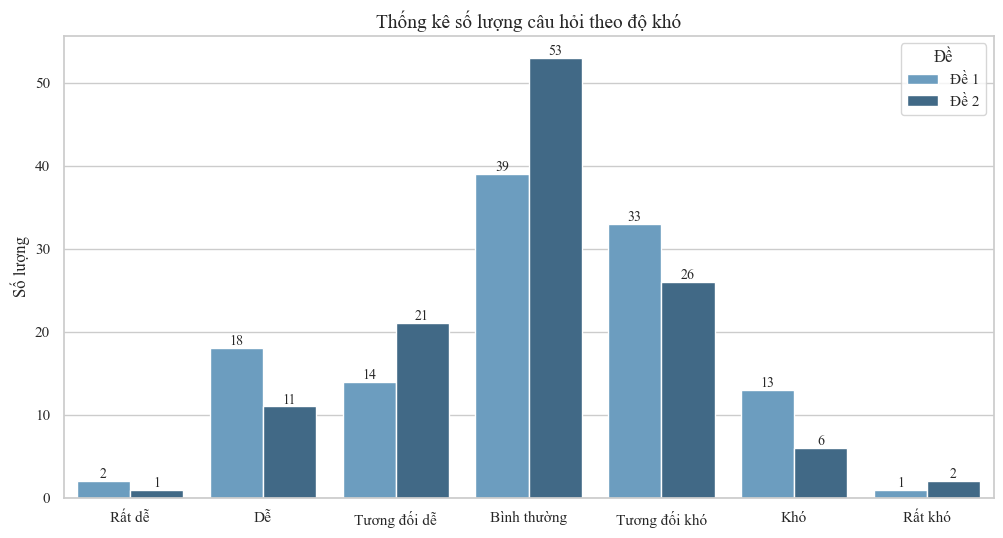

In [116]:
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] 
plt.figure(figsize=(12, 6))

b1 = b_1.copy()
b2 = b_2.copy()

b1["Đề"] = "Đề 1"
b2["Đề"] = "Đề 2"
merged = pd.concat([b1, b2], ignore_index=True)
sns.countplot(data=merged, x='Phân loại', palette='Blues_d', order=['Rất dễ', 'Dễ', 'Tương đối dễ', 'Bình thường', 
                                                                    'Tương đối khó', 'Khó','Rất khó'], hue='Đề')
plt.title('Thống kê số lượng câu hỏi theo độ khó', fontsize=14)
plt.xlabel(None)
plt.ylabel('Số lượng')

#thêm nhãn trên mỗi cột
for p in plt.gca().patches:
    height = p.get_height()
    if height >0:
        plt.gca().annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=10)


In [117]:
b1['Dạng câu hỏi'] = (
    b1.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

b2['Dạng câu hỏi'] = (
    b2.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

C:\Users\Administra\AppData\Local\Temp\ipykernel_36036\1234313323.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=b1, x='Dạng câu hỏi', y='CTT', palette='Blues_d', ax=axes[0])
C:\Users\Administra\AppData\Local\Temp\ipykernel_36036\1234313323.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=b2, x='Dạng câu hỏi', y='CTT', palette='Purples_d', ax=axes[1])


Text(0.5, 0.98, 'Chênh lệch độ khó mỗi đề thi theo dạng câu hỏi')

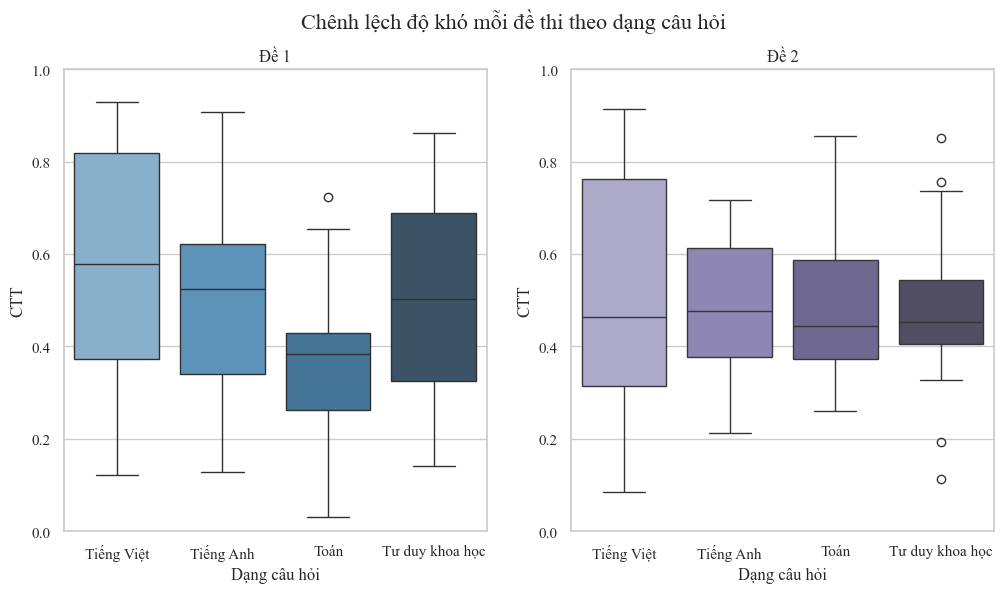

In [118]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))
sns.boxplot(data=b1, x='Dạng câu hỏi', y='CTT', palette='Blues_d', ax=axes[0])
axes[0].set_title('Đề 1')
axes[0].set_ylim(0,1)
sns.boxplot(data=b2, x='Dạng câu hỏi', y='CTT', palette='Purples_d', ax=axes[1])
axes[1].set_title('Đề 2')
axes[1].set_ylim(0,1)
plt.suptitle('Chênh lệch độ khó mỗi đề thi theo dạng câu hỏi', fontsize=16)

In [119]:
a_1, a_2 =  pd.DataFrame(), pd.DataFrame()
for data in [df_TV1, df_TA1, df_TO1, df_KH1]:
    data = tinh_diem(data)
    a = (ctt.cal_disc(data[data['Null'] < 30])) # loại những thí sinh không thi 1 phần (bỏ toàn bộ câu hỏi của phần thi đó)
    a_1 = pd.concat([a_1, a], axis=0)

for data in [df_TV2, df_TA2, df_TO2, df_KH2]:
    data = tinh_diem(data)
    a = (ctt.cal_disc(data[data['Null'] < 30])) # loại những thí sinh không thi 1 phần (bỏ toàn bộ câu hỏi của phần thi đó)
    a_2 = pd.concat([a_2, a], axis=0)

a_1 = a_1.rename({0: 'D-Index'}, axis=1)
a_2 = a_2.rename({0: 'D-Index'}, axis=1)

In [120]:
def a_category(disc):
    if disc <= 0:
        return 'Kém'
    elif disc <= 0.20:
        return 'Chưa tốt'
    elif disc <= 0.40:
        return 'Chấp nhận được'
    elif disc <= 0.60:
        return 'Tương đối tốt'
    elif disc <= 0.80:
        return 'Tốt'
    elif disc <= 1.0:
        return 'Rất tốt'
    else:
        return 'Quá tốt'
    
a_1['Phân loại'] = a_1['D-Index'].apply(a_category)
a_2['Phân loại'] = a_2['D-Index'].apply(a_category)

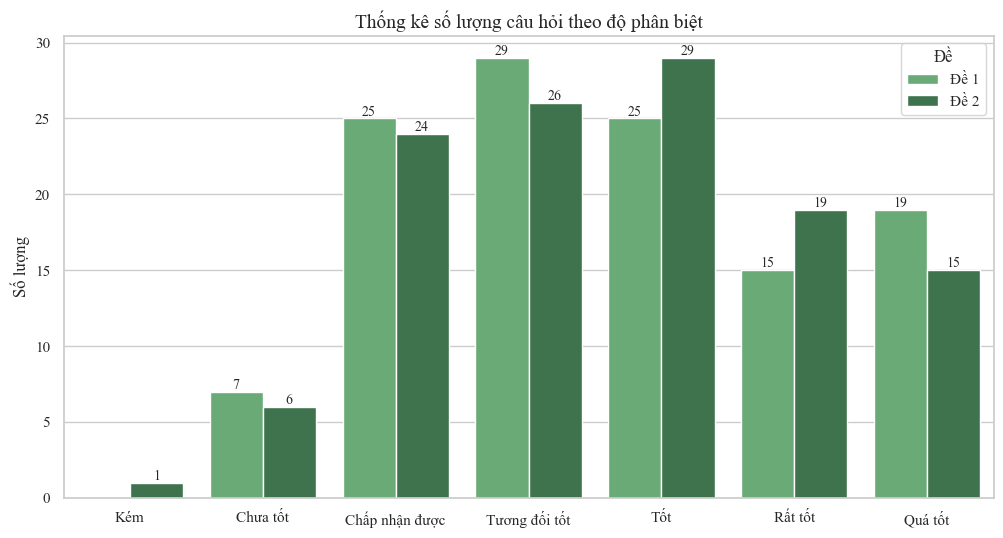

In [121]:
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] 
plt.figure(figsize=(12, 6))

a1 = a_1.copy()
a2 = a_2.copy()

a1["Đề"] = "Đề 1"
a2["Đề"] = "Đề 2"
merged = pd.concat([a1, a2], ignore_index=True)
sns.countplot(data=merged, x='Phân loại', palette='Greens_d', order=['Kém', 'Chưa tốt', 'Chấp nhận được', 'Tương đối tốt', 
                                                                    'Tốt', 'Rất tốt','Quá tốt'], hue='Đề')
plt.title('Thống kê số lượng câu hỏi theo độ phân biệt', fontsize=14)
plt.xlabel(None)
plt.ylabel('Số lượng')

#thêm nhãn trên mỗi cột
for p in plt.gca().patches:
    height = p.get_height()
    if height >0:
        plt.gca().annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=10)


In [122]:
a1['Dạng câu hỏi'] = (
    a1.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

a2['Dạng câu hỏi'] = (
    a2.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

C:\Users\Administra\AppData\Local\Temp\ipykernel_36036\736327964.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=a1, x='Dạng câu hỏi', y='D-Index', palette='viridis_d', ax=axes[0])
C:\Users\Administra\AppData\Local\Temp\ipykernel_36036\736327964.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=a2, x='Dạng câu hỏi', y='D-Index', palette='plasma_d', ax=axes[1])


Text(0.5, 0.98, 'Chênh lệch độ phân biệt mỗi đề thi theo dạng câu hỏi')

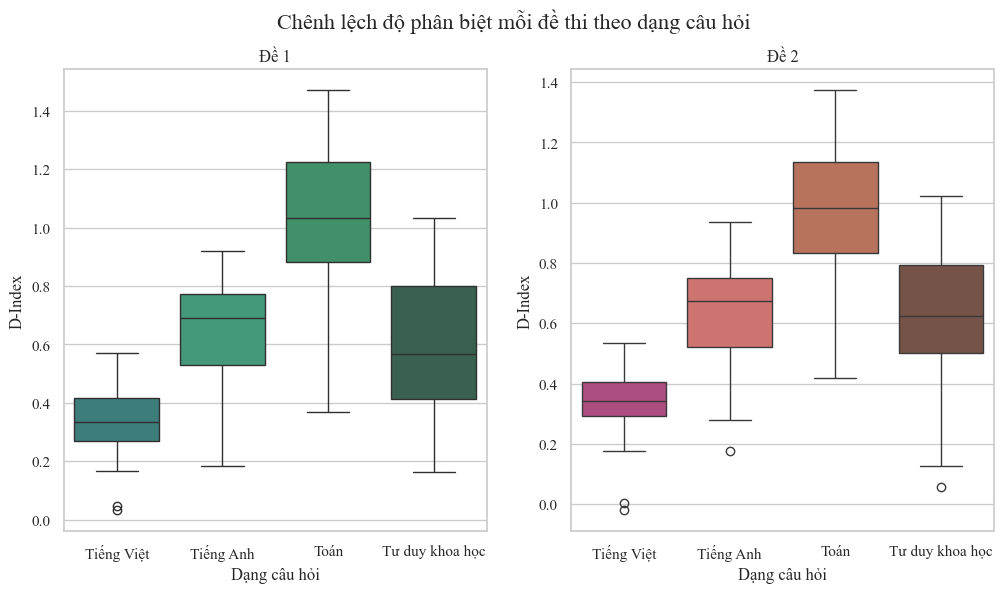

In [123]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))
sns.boxplot(data=a1, x='Dạng câu hỏi', y='D-Index', palette='viridis_d', ax=axes[0])
axes[0].set_title('Đề 1')
sns.boxplot(data=a2, x='Dạng câu hỏi', y='D-Index', palette='plasma_d', ax=axes[1])
axes[1].set_title('Đề 2')
plt.suptitle('Chênh lệch độ phân biệt mỗi đề thi theo dạng câu hỏi', fontsize=16)

In [124]:
def do_nhieu(data: pd.DataFrame, chamdiem, answer: pd.DataFrame, start, end):
    # Merge 1 lần
    data = data.merge(chamdiem[['SBD', 'Raw', 'Null']], on='SBD', how='left')
    ans_row = answer.iloc[0]

    # DataFrame lưu kết quả tổng hợp
    df_all = pd.DataFrame(columns=["A", "B", "C", "D", "Ans"])

    # Lọc thí sinh hợp lệ
    valid = data[data['Null'] < 30]

    for stt in range(start, end + 1):
        std = valid['Raw'].std()
        cau_col = f"Cau{stt}"
        correct = ans_row[cau_col]

        pbcc_dict = {}

        for opt in ["A", "B", "C", "D"]:

            true_group  = valid.loc[valid[cau_col] == opt, 'Raw']
            false_group = valid.loc[valid[cau_col] != opt, 'Raw']
            if true_group.shape[0] == 0 or false_group.shape[0] == 0:
                pb = np.nan
            else:
                p = true_group.shape[0] / valid[cau_col].shape[0]
                pb = ctt.cal_pbcc(true_group, false_group, std, p)

            pbcc_dict[opt] = pb

        # PBCC của đáp án đúng
        pbcc_ans = pbcc_dict.get(correct, np.nan)

        # Append 1 dòng vào df_all
        df_all.loc[f'Cau{stt}'] = [
            pbcc_dict["A"],
            pbcc_dict["B"],
            pbcc_dict["C"],
            pbcc_dict["D"],
            pbcc_ans
        ]

    return df_all


In [125]:
nhieu_1 = pd.concat([do_nhieu(data=df_dot1, answer=da_1, chamdiem=df_TV1, start=1, end=30),
                     do_nhieu(data=df_dot1, answer=da_1, chamdiem=df_TA1, start=31, end=60),
                    do_nhieu(data=df_dot1, answer=da_1, chamdiem=df_TO1, start=61, end=90),
                    do_nhieu(data=df_dot1, answer=da_1, chamdiem=df_KH1, start=91, end=120),], axis=0)

In [126]:
nhieu_1

,A,B,C,D,Ans
Cau1,-0.090698,-0.077724,0.145350,-0.050370,0.145350
Cau2,-0.077654,-0.164355,0.200580,-0.258847,0.200580
Cau3,0.023497,0.010622,0.020272,-0.064765,0.010622
Cau4,0.098663,0.055808,-0.015382,-0.074254,0.055808
Cau5,-0.137573,0.120029,-0.081774,0.114395,0.120029
...,...,...,...,...,...
Cau116,0.093254,0.231577,0.015300,0.069040,0.231577
Cau117,-0.146751,-0.147345,-0.014308,0.505123,0.505123
Cau118,-0.185613,-0.029800,0.259071,0.210703,0.210703
Cau119,-0.087406,0.508710,-0.103076,-0.149028,0.508710


In [127]:
nhieu_2 = pd.concat([
    do_nhieu(data=df_dot2, answer=da_2, chamdiem=df_TV2, start=1, end=30),
    do_nhieu(data=df_dot2, answer=da_2, chamdiem=df_TA2, start=31, end=60),
    do_nhieu(data=df_dot2, answer=da_2, chamdiem=df_TO2, start=61, end=90),
    do_nhieu(data=df_dot2, answer=da_2, chamdiem=df_KH2, start=91, end=120),
], axis=0)


In [128]:
nhieu_2

,A,B,C,D,Ans
Cau1,-0.112050,-0.119164,-0.238992,0.372054,0.372054
Cau2,-0.181301,-0.227150,-0.068436,0.315619,0.315619
Cau3,-0.072206,-0.204496,0.255094,-0.106073,0.255094
Cau4,0.265416,-0.013612,-0.107189,-0.129261,0.265416
Cau5,-0.039716,-0.208780,-0.179729,0.298750,0.298750
...,...,...,...,...,...
Cau116,-0.110480,0.402168,-0.213573,-0.098925,0.402168
Cau117,-0.198114,-0.057453,-0.174101,0.376236,0.376236
Cau118,-0.124422,-0.235191,-0.159096,0.557978,0.557978
Cau119,0.519316,-0.120816,-0.161446,-0.078337,0.519316


In [129]:
# hàm phân loại độ nhiễu câu hỏi
def label_distract(data):
    scale = 0
    for col in data.drop(columns='Ans').index:  # bỏ qua cột đáp án đúng
        if data[col] == data['Ans']:
            continue
        else:
            scale += (data[col]<0)
    if scale == 3:
        return "Tốt"
    elif scale == 2:
        return "Bình thường"
    elif scale == 1:
        return "Yếu"
    else:  
        return "Kém"

In [130]:
nhieu_1['Mức độ nhiễu'] = nhieu_1.apply(label_distract, axis=1)
nhieu_1

,A,B,C,D,Ans,Mức độ nhiễu
Cau1,-0.090698,-0.077724,0.145350,-0.050370,0.145350,Tốt
Cau2,-0.077654,-0.164355,0.200580,-0.258847,0.200580,Tốt
Cau3,0.023497,0.010622,0.020272,-0.064765,0.010622,Yếu
Cau4,0.098663,0.055808,-0.015382,-0.074254,0.055808,Bình thường
Cau5,-0.137573,0.120029,-0.081774,0.114395,0.120029,Bình thường
...,...,...,...,...,...,...
Cau116,0.093254,0.231577,0.015300,0.069040,0.231577,Kém
Cau117,-0.146751,-0.147345,-0.014308,0.505123,0.505123,Tốt
Cau118,-0.185613,-0.029800,0.259071,0.210703,0.210703,Bình thường
Cau119,-0.087406,0.508710,-0.103076,-0.149028,0.508710,Tốt


In [131]:
nhieu_2['Mức độ nhiễu'] = nhieu_2.apply(label_distract, axis=1)
nhieu_2

,A,B,C,D,Ans,Mức độ nhiễu
Cau1,-0.112050,-0.119164,-0.238992,0.372054,0.372054,Tốt
Cau2,-0.181301,-0.227150,-0.068436,0.315619,0.315619,Tốt
Cau3,-0.072206,-0.204496,0.255094,-0.106073,0.255094,Tốt
Cau4,0.265416,-0.013612,-0.107189,-0.129261,0.265416,Tốt
Cau5,-0.039716,-0.208780,-0.179729,0.298750,0.298750,Tốt
...,...,...,...,...,...,...
Cau116,-0.110480,0.402168,-0.213573,-0.098925,0.402168,Tốt
Cau117,-0.198114,-0.057453,-0.174101,0.376236,0.376236,Tốt
Cau118,-0.124422,-0.235191,-0.159096,0.557978,0.557978,Tốt
Cau119,0.519316,-0.120816,-0.161446,-0.078337,0.519316,Tốt


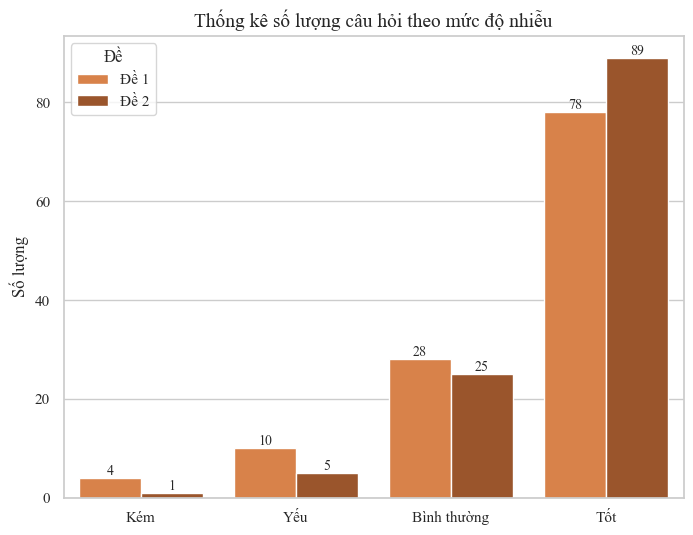

In [132]:
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] 
plt.figure(figsize=(8, 6))

nhieu1_copy = nhieu_1.copy()
nhieu2_copy = nhieu_2.copy()

nhieu1_copy["Đề"] = "Đề 1"
nhieu2_copy["Đề"] = "Đề 2"
merged = pd.concat([nhieu1_copy, nhieu2_copy], ignore_index=True)
sns.countplot(data=merged, x='Mức độ nhiễu', palette='Oranges_d', order=['Kém', 'Yếu', 'Bình thường', 'Tốt'], hue='Đề')
plt.title('Thống kê số lượng câu hỏi theo mức độ nhiễu', fontsize=14)
plt.xlabel(None)
plt.ylabel('Số lượng')

#thêm nhãn trên mỗi cột
for p in plt.gca().patches:
    height = p.get_height()
    if height >0:
        plt.gca().annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=10)
